<a href="https://colab.research.google.com/github/chetankodigantiML/ECGR4105-F26/blob/main/HW3_Benchmarking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn import metrics

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Problem 1

In [ ]:
diabetes_data = pd.read_csv('/content/drive/My Drive/Fall26/ECGR4105/HW3/diabetes.csv')
#diabetes_data.head()

In [ ]:
diabetes_colm = ['Pregnancies',	'Glucose',	'BloodPressure',	'SkinThickness',	'Insulin',	'BMI',	'DiabetesPedigreeFunction',	'Age']
diabetes_data[diabetes_colm] = scaler.fit_transform(diabetes_data[diabetes_colm])

In [ ]:
d_train, d_test = train_test_split(diabetes_data, train_size=0.8, test_size=0.2, random_state=42)

d_x_train = d_train[diabetes_colm]
d_y_train = d_train['Outcome']
d_x_test = d_test[diabetes_colm]
d_y_test = d_test['Outcome']

In [ ]:
d_classifier = LogisticRegression(random_state=0)
d_classifier.fit(d_x_train, d_y_train)
d_y_pred = d_classifier.predict(d_x_test)

d_cfn_mtx = confusion_matrix(d_y_test, d_y_pred)
d_cfn_mtx

array([[86, 13],
       [23, 32]])

In [ ]:
d_acc = metrics.accuracy_score(d_y_test, d_y_pred)
d_prc = metrics.precision_score(d_y_test, d_y_pred)
d_rec = metrics.recall_score(d_y_test, d_y_pred)
d_f1 = 2 * d_prc * d_rec / (d_prc + d_rec)
print('Accuracy: ', round(d_acc,2))
print('Precision: ', round(d_prc,2))
print('Recall: ', round(d_rec,2))
print('F1: ', round(d_f1,2))

Accuracy:  0.77
Precision:  0.71
Recall:  0.58
F1:  0.64


Text(0.5, 23.52222222222222, 'Predicted Values')

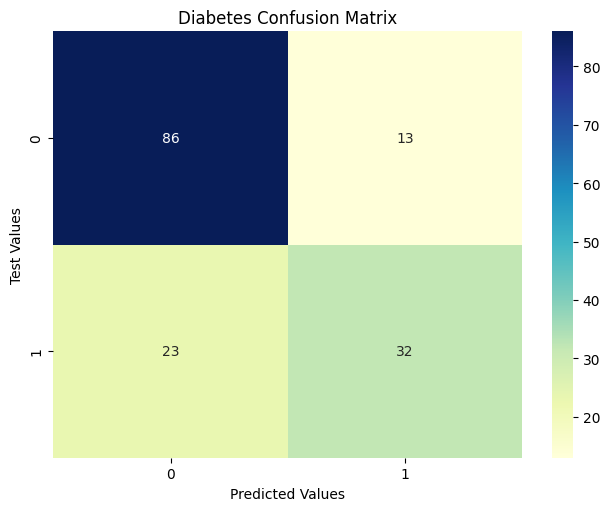

In [ ]:
class_names = [0,1]
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)

sns.heatmap(pd.DataFrame(d_cfn_mtx), annot=True, cmap="YlGnBu", fmt='g')
plt.tight_layout()
plt.title("Diabetes Confusion Matrix")
plt.ylabel("Test Values")
plt.xlabel("Predicted Values")

# Problem 2

In [ ]:
cancer_data = pd.read_csv('/content/drive/My Drive/Fall26/ECGR4105/HW3/Cancer.csv')

cancer_data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [ ]:
cancer_colm = ['radius_mean',	'texture_mean',	'perimeter_mean',	'area_mean',	'smoothness_mean',	'compactness_mean',	'concavity_mean',	'concave points_mean',	'symmetry_mean',	'fractal_dimension_mean',	'radius_se',	'texture_se',	'perimeter_se',	'area_se',	'smoothness_se'	,'compactness_se',	'concavity_se',	'concave points_se'	,'symmetry_se',	'fractal_dimension_se'	,'radius_worst',	'texture_worst',	'perimeter_worst',	'area_worst',	'smoothness_worst',	'compactness_worst',	'concavity_worst'	,'concave points_worst'	,'symmetry_worst'	,'fractal_dimension_worst']

scaler = MinMaxScaler()
cancer_data[cancer_colm] = scaler.fit_transform(cancer_data[cancer_colm])


In [ ]:
c_train, c_test = train_test_split(cancer_data, train_size=0.8, test_size=0.2, random_state=42)

c_x_train = c_train[cancer_colm]
c_y_train = c_train['diagnosis']
c_x_test = c_test[cancer_colm]
c_y_test = c_test['diagnosis']

In [ ]:
c_classifier = LogisticRegression(random_state=0, class_weight={'B':5,'M':1})
c_classifier.fit(c_x_train, c_y_train)

c_y_pred = c_classifier.predict(c_x_test)

c_cfn_mtx = confusion_matrix(c_y_test, c_y_pred)
c_cfn_mtx

array([[71,  0],
       [ 7, 36]])

In [ ]:
c_acc = metrics.accuracy_score(c_y_test, c_y_pred)
c_prc = metrics.precision_score(c_y_test, c_y_pred, pos_label='M')
c_rec = metrics.recall_score(c_y_test, c_y_pred, pos_label='M')
c_f1 = 2 * c_prc * c_rec / (c_prc + c_rec)
print('Accuracy: ', round(c_acc,2))
print('Precision: ', round(c_prc,2))
print('Recall: ', round(c_rec,2))
print('F1: ', round(c_f1,2))

Accuracy:  0.94
Precision:  1.0
Recall:  0.84
F1:  0.91


Text(0.5, 23.52222222222222, 'Predicted Values')

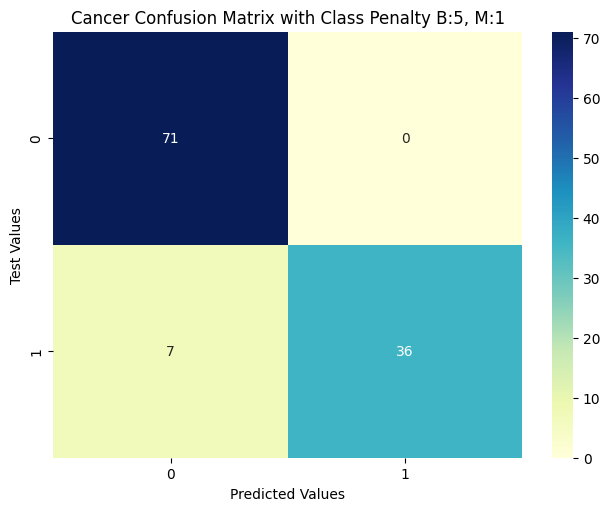

In [ ]:
class_names = [0,1]
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)

sns.heatmap(pd.DataFrame(c_cfn_mtx), annot=True, cmap="YlGnBu", fmt='g')
plt.tight_layout()
plt.title("Cancer Confusion Matrix with Class Penalty B:5, M:1")
plt.ylabel("Test Values")
plt.xlabel("Predicted Values")